# ACD example: ADHDP (paper-style) on ImprovedB747Env

This notebook demonstrates `tensoraerospace.agent.ADHDP` in a **paper-aligned training schedule**:

- **Critic** learns action-dependent cost-to-go \(J(R,a)\) via online TD.
- **Policy improvement** is done either by:
  - training an **actor** \(\pi(R)\), or
  - using a **critic-gradient teacher** \(a^*(R) \approx \arg\min_a J(R,a)\) (HDPy-style).

For this environment, the most stable setup is:
- **Baseline warmup (PID/PD) for N episodes**: baseline is used **only** to generate safe trajectories so the critic learns.
- After warmup, **baseline is disabled** and the actor is trained by **distilling** the critic-gradient teacher.

Notes:
- No replay buffer / no target networks.
- Paper Section III stresses stability + **persistent excitation**: we randomize \(R(0)\)/reference instead of relying on large action noise.
- In `POLICY_MODE="residual"`, baseline is computed **from observations only** (safe on a fresh env instance).



In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "tensoraerospace").exists():
            return p
    return start


# Make sure repo root + example helpers are importable
HERE = Path.cwd().resolve()
ROOT = _find_repo_root(HERE)
EX_DIR = ROOT / "example" / "dynamic-programming"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(EX_DIR))

import numpy as np
import tensoraerospace

from tensoraerospace.agent import ADHDP
from acd_b747_common import make_env_b747_sine, plot_rollout, rollout

print("repo root:", ROOT)
print("tensoraerospace from:", Path(tensoraerospace.__file__).resolve())



repo root: /Users/asmazaev/TensorAeroSpace-Origin
tensoraerospace from: /Users/asmazaev/TensorAeroSpace-Origin/tensoraerospace/__init__.py


In [ ]:
# ---- User controls ----
DT = 0.1
N_STEPS = 300
REWARD_MODE = "tracking"  # "tracking" or "step_response"

# Observation
INCLUDE_REFERENCE_IN_OBS = True  # recommended for ADHDP stability

# Sine reference (pitch)
SINE_AMP_DEG = 1.0
SINE_FREQ_HZ = 0.05

# ADHDP
DEVICE = "mps"
GAMMA = 0.99
HIDDEN_SIZE = 128

# Training
# NOTE: baseline warmup + actor distillation needs a decent budget.
TRAIN_EPISODES = 600
MAX_STEPS_PER_EPISODE = N_STEPS

# Canonical ADHDP: no replay buffer, no target networks
USE_REPLAY = False
REPLAY_CAPACITY = 50_000
BATCH_SIZE = 64
UPDATES_PER_STEP = 1

USE_TARGET_NETWORKS = False
TAU = 0.02

# Learning rates: critic should move faster than actor (avoid actor drift)
# Paper-strict/direct is much more fragile -> use a very small actor LR.
ACTOR_LR = 1e-5
CRITIC_LR = 5e-4

# Per-step update multipliers (MATLAB-style "epochs per step")
CRITIC_UPDATES_PER_STEP = 1
ACTOR_UPDATES_PER_STEP = 1

# Strict paper mode (Prokhorov & Wunsch):
# - no residual baseline in the executed policy
# - no baseline substitution during critic-only phases
# - no behavior-cloning regularizer
PAPER_STRICT = True

# Action selection:
# - "actor": standard π(s) network (can drift in strict/direct)
# - "critic_gradient": choose action by directly minimizing critic J(s,a) w.r.t. a (HDPy-style)
ACTION_SELECTION = "actor"
# Conservative trust-region-ish settings (prevents exploiting an inaccurate critic early)
ACTION_GRAD_STEPS = 10
# Slightly softer teacher (reduces boundary-chasing / overshoot)
ACTION_GRAD_LR = 0.02
ACTION_GRAD_STEP_CLIP = 0.03
ACTION_GRAD_U_L2 = 0.5
ACTION_GRAD_DU_L2 = 4.0

# Actor training mode
# - "minimize_critic": can drift when critic is imperfect
# - "distill_critic_gradient": train actor to imitate teacher argmin_a J(s,a)
ACTOR_UPDATE_MODE = "distill_critic_gradient"
ACTOR_DISTILL_COEF = 1.0
ACTOR_DISTILL_STEPS = 10
ACTOR_DISTILL_LR = 0.03

# Key trick: during distillation, execute the teacher policy (critic-gradient) for rollouts,
# and train the actor to imitate it. This prevents actor-induced OOD states.
# Once the actor matches the teacher well, you can set this to False to fully switch to actor rollouts.
DISTILL_EXECUTE_TEACHER = True
TEACHER_ROLLOUT_NOISE_STD = 0.0  # keep 0.0 for stability; try 0.01 if critic needs more excitation

# Policy composition
# In paper-strict mode the policy should be "direct" (actor outputs the full action).
POLICY_MODE = "direct"  # "direct" or "residual"
RESIDUAL_SCALE = 0.0
USE_BASELINE_IN_CRITIC_PHASES = False

# HDPy-style action momentum (no baseline):
# For teacher rollouts, a little momentum can reduce jitter.
ACTION_MOMENTUM = 0.2

# Baseline-free safety envelope (normalized action units): clamp to [-u_max, u_max].
# Slightly tighter reduces overshoot; increase if tracking amplitude is too low.
ACTION_MAX_ABS = 0.35

# Paper-style exploration: prefer trajectory variety (randomize R(0)/reference) over action noise.
# With teacher rollouts enabled, keep actor-side exploration at 0 to avoid rare termination episodes.
EXPLORATION_STD = 0.0
INITIAL_STATE_NOISE_STD = 0.0   # start from 0.0; increase to 0.005..0.02 if training is stuck
REFERENCE_ROLL_STEPS = 80       # random roll in [-N, +N] timesteps each episode
REFERENCE_NOISE_STD = 0.0       # std in radians added to reference_signal

# Paper-style: train on utility U (env cost_total) rather than shaped reward
ADHDP_USE_ENV_COST = True

# Baseline stabilizer settings (used for comparison + warm-start)
# Note: for BASELINE_TYPE="pid", ADHDP uses a PID-like baseline with derivative-on-measurement
# computed from observation (matching the spirit of tensoraerospace.agent.pid.PID, but safe for eval on a fresh env).
BASELINE_TYPE = "pid"  # "pid" or "pd"
BASELINE_KP = -24.6295
BASELINE_KI = -0.2486
BASELINE_KD = -7.8179

# Paper-style warm start:
# - for POLICY_MODE="direct": pretrain actor to mimic baseline
# - for POLICY_MODE="residual": actor is a residual, so the right warm-start is near-zero
ADHDP_WARMSTART_ACTOR_EPISODES = 20
ADHDP_WARMSTART_ACTOR_EPOCHS = 5

# Baseline warmup (recommended): first N episodes run ONLY the stabilizing baseline (PID/PD)
# to collect safe trajectories and train the critic. After this phase baseline is disabled.
BASELINE_WARMUP_EPISODES = 200  # 100..300 works; must be < TRAIN_EPISODES

# Paper-style schedule: keep actor fixed for first N episodes so critic learns on a stable policy
# If BASELINE_WARMUP_EPISODES > 0, you can usually set this to 0.
ADHDP_CRITIC_WARMUP_EPISODES = 0

# Alternating cycles (Section III, Prokhorov & Wunsch 1997): critic-only then actor-only.
# Quote (paper): "two training cycles: critic's and action's. We always start with critic's adaptation
# alternating it with action's" and "The action's training cycle should be repeated ... while keeping
# the critic's weights fixed" (see `Adaptive Critic Designs.md`, around lines ~948-955 and ~1049-1054).
#
# In this notebook:
# - ADHDP_CRITIC_CYCLE_EPISODES ≈ Nc (episodes where we update the critic, freeze actor)
# - ADHDP_ACTION_CYCLE_EPISODES ≈ Na (episodes where we update the actor, freeze critic)
# Paper-strict/direct: make actor cycles short and infrequent.
# With distillation, we can afford a bit more actor training, but still keep critic ahead.
ADHDP_CRITIC_CYCLE_EPISODES = 20
ADHDP_ACTION_CYCLE_EPISODES = 5

# Practical stabilization:
# In paper-strict mode we disable BC.
ADHDP_ACTOR_BC_L2 = 0.0
ADHDP_ACTOR_BC_DECAY = 1.0



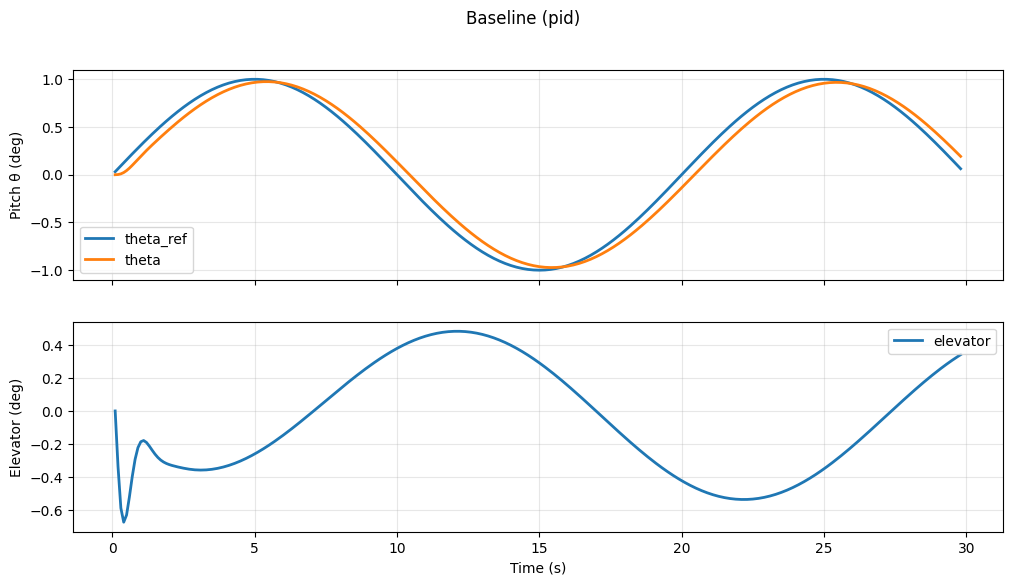

metrics: {'rmse_theta_deg': 0.09518628134597934, 'mae_theta_deg': 0.085590508441739, 'max_abs_theta_deg': 0.14231985444533443, 'episode_return': -0.0037671013898498817}
Training... episodes= 600 agent= ADHDP


ADHDP train: 100%|██████████| 600/600 [1:02:21<00:00,  6.24s/ep, a_loss=7.55e-10, c_loss=0, phase=teacher_rollout, rew=-0.204, steps=298] 


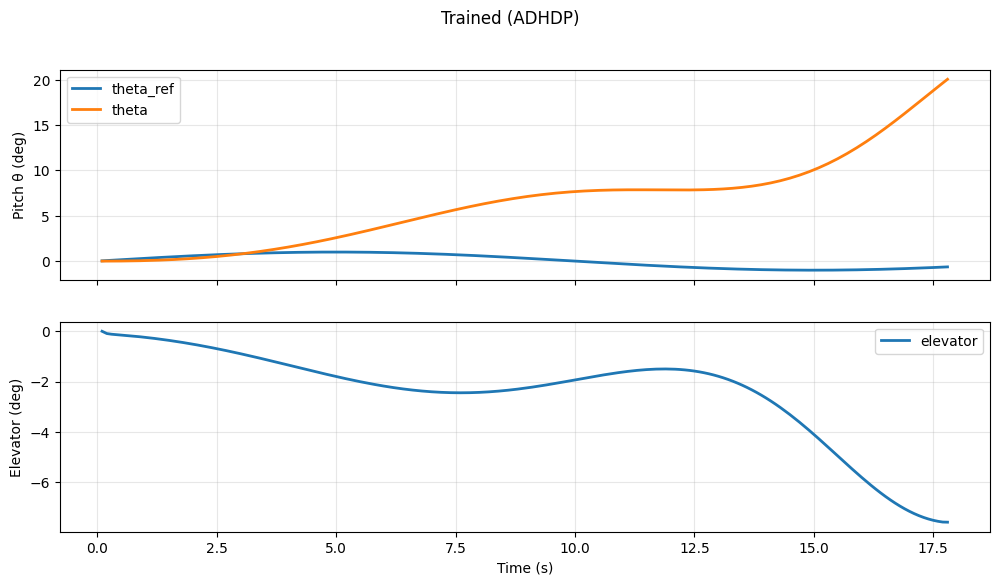

metrics: {'rmse_theta_deg': 8.341192967760673, 'mae_theta_deg': 6.429647931878566, 'max_abs_theta_deg': 20.69544519999667, 'episode_return': -115.39779854483828}


In [ ]:
def make_env():
    return make_env_b747_sine(
        dt=DT,
        n_steps=N_STEPS,
        reward_mode=REWARD_MODE,
        sine_amp_deg=SINE_AMP_DEG,
        sine_freq_hz=SINE_FREQ_HZ,
        include_reference_in_obs=bool(INCLUDE_REFERENCE_IN_OBS),
    )

# Baseline (PD) — comparison only
base_kind = str(BASELINE_TYPE).lower().strip()
baseline_kwargs = dict(
    make_env=make_env(),
    agent=None,
    baseline=base_kind,
)
# rollout() supports PID only when agent is None
if base_kind == "pid":
    baseline = rollout(
        make_env(),
        agent=None,
        baseline=base_kind,
        pid_kp=BASELINE_KP,
        pid_ki=BASELINE_KI,
        pid_kd=BASELINE_KD,
        pid_mode="norm",
    )
else:
    baseline = rollout(
        make_env(),
        agent=None,
        baseline=base_kind,
        pd_kp=BASELINE_KP,
        pd_kd=BASELINE_KD,
    )
plot_rollout(baseline, title=f"Baseline ({base_kind})")

agent = ADHDP(
    env=make_env(),
    paper_strict=bool(PAPER_STRICT),
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    hidden_size=HIDDEN_SIZE,
    device=DEVICE,
    # Policy composition
    policy_mode=str(POLICY_MODE),
    residual_scale=float(RESIDUAL_SCALE),
    use_baseline_in_critic_phases=bool(USE_BASELINE_IN_CRITIC_PHASES),
    action_momentum=float(ACTION_MOMENTUM),
    action_max_abs=float(ACTION_MAX_ABS),
    action_selection=str(ACTION_SELECTION),
    action_grad_steps=int(ACTION_GRAD_STEPS),
    action_grad_lr=float(ACTION_GRAD_LR),
    action_grad_step_clip=float(ACTION_GRAD_STEP_CLIP),
    action_grad_u_l2=float(ACTION_GRAD_U_L2),
    action_grad_du_l2=float(ACTION_GRAD_DU_L2),
    actor_update_mode=str(ACTOR_UPDATE_MODE),
    actor_distill_coef=float(ACTOR_DISTILL_COEF),
    actor_distill_steps=int(ACTOR_DISTILL_STEPS),
    actor_distill_lr=float(ACTOR_DISTILL_LR),
    distill_execute_teacher=bool(DISTILL_EXECUTE_TEACHER),
    teacher_rollout_noise_std=float(TEACHER_ROLLOUT_NOISE_STD),
    # Paper-style exploration: prefer varied trajectories over action noise
    exploration_std=float(EXPLORATION_STD),
    initial_state_noise_std=float(INITIAL_STATE_NOISE_STD),
    reference_roll_steps=int(REFERENCE_ROLL_STEPS),
    reference_noise_std=float(REFERENCE_NOISE_STD),
    # MATLAB-style "epochs per step"
    critic_updates_per_step=int(CRITIC_UPDATES_PER_STEP),
    actor_updates_per_step=int(ACTOR_UPDATES_PER_STEP),
    log_every_updates=500,
    # Baseline stabilizer used for warm-start + optional BC regularizer
    baseline_type=base_kind,
    baseline_kp=BASELINE_KP,
    baseline_ki=BASELINE_KI,
    baseline_kd=BASELINE_KD,
    # Paper-style warm-start + schedules
    warmstart_actor_episodes=int(ADHDP_WARMSTART_ACTOR_EPISODES),
    warmstart_actor_epochs=int(ADHDP_WARMSTART_ACTOR_EPOCHS),
    baseline_warmup_episodes=int(BASELINE_WARMUP_EPISODES),
    critic_warmup_episodes=int(ADHDP_CRITIC_WARMUP_EPISODES),
    critic_cycle_episodes=int(ADHDP_CRITIC_CYCLE_EPISODES),
    action_cycle_episodes=int(ADHDP_ACTION_CYCLE_EPISODES),
    use_env_cost=bool(ADHDP_USE_ENV_COST),
    # Optional stabilization
    actor_bc_l2=float(ADHDP_ACTOR_BC_L2),
    actor_bc_decay=float(ADHDP_ACTOR_BC_DECAY),
)

print("Training...", "episodes=", TRAIN_EPISODES, "agent=", "ADHDP")
agent.train(num_episodes=int(TRAIN_EPISODES), max_steps=int(MAX_STEPS_PER_EPISODE), show_progress=True)

trained = rollout(make_env(), agent=agent, deterministic=True)
plot_rollout(trained, title="Trained (ADHDP)")

